In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import yaml
import unicodedata
from helpers_finalizacion_carrera import get_egresados_computacion, plot_todos_anios_egreso, plot_tiempo_cursando

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

## Computación

In [4]:
materias_computacion = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias de la Computación']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_computacion

,materia,cantidad
0,ALGEBRA I,10599
1,ANALISIS II,7125
2,PROBABILIDADES Y ESTADISTICA,5038
3,ALGORITMOS Y ESTRUCTURAS DE DATOS II,4531
4,ALGORITMOS Y ESTRUCTURAS DE DATOS I,4362
...,...,...
350,REDUCCIONES Y CAUSALIDAD,1
351,FISICA DE ESTADISTICA DE LOS SISTEMAS SOCIO-EC...,1
352,MODELOS MATEMATICOS Y OPTIMIZACION,1
353,INTRODUCCION A LA FOTOGRAFIA 3D,1


In [5]:
with open('../../constants/materias_computacion.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [6]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias = list(set(materias))
materias

['COMPLEJIDAD COMPUTACIONAL',
 'LOGICA Y COMPUTABILIDAD',
 'INGENIERIA DE SOFTWARE',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS',
 'ALGEBRA I',
 'REDES DE COMUNICACIONES Y COMPUTO DISTRIBUIDO',
 'SEMINARIO SOBRE TECNOLOGIA Y SOCIEDAD',
 'ORGANIZACION DEL COMPUTADOR II',
 'ORGANIZACION DEL COMPUTADOR I',
 'ANALISIS I',
 'BASE DE DATOS',
 'PROGRAMACION CONCURRENTE Y PARALELA',
 'INTRODUCCION A LA PROGRAMACION',
 'TESIS DE LICENCIATURA',
 'ARQUITECTURA Y ORGANIZACION DE COMPUTADORES',
 'PRACTICA SOCIAL EDUCATIVA',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS II',
 'PARADIGMAS DE PROGRAMACION',
 'INGENIERIA DE SOFTWARE II',
 'INGENIERIA DE SOFTWARE I',
 'TECNICAS DE DISENO DE ALGORITMOS',
 'TEORIA DE LAS COMUNICACIONES',
 'ALGORITMOS Y ESTRUCTURAS DE DATOS I',
 'METODOS NUMERICOS',
 'TEORIA DE LENGUAJES',
 'ANALISIS II',
 'ALGEBRA LINEAL COMPUTACIONAL',
 'PROBABILIDADES Y ESTADISTICA',
 'SISTEMAS OPERATIVOS',
 'ESTADISTICA COMPUTACIONAL',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION',
 'LENGUAJES FOR

In [7]:
len(materias)

34

In [8]:
materias_computacion[materias_computacion['materia'].isin(materias)].shape

(29, 2)

No todas las carreras aparecen, revisamos cuales faltan

In [9]:
materias_en_actas = materias_computacion['materia'].tolist()

In [10]:
[m for m in materias if m not in materias_en_actas]

['REDES DE COMUNICACIONES Y COMPUTO DISTRIBUIDO',
 'PROGRAMACION CONCURRENTE Y PARALELA',
 'PRACTICA SOCIAL EDUCATIVA',
 'ESTADISTICA COMPUTACIONAL',
 'ALMACENAMIENTO Y RECUPERACION DE LA INFORMACION']

In [11]:
materias_computacion[materias_computacion['materia'].isin(materias)].sort_values(by='cantidad', ascending=False).shape

(29, 2)

Todas se corresponden con materias del nuevo plan de computación, que ninguna de las materias puede estar indicando que todavía no se dieron.

A su vez, todas estas materias tienen correlativa excepto 'PRACTICA SOCIAL EDUCATIVA'. Esto nos daría el indicio de que no hay egresados con el nuevo plan todavía.

## Calculo de egresados

* Condición 1: el DNI tiene "TESIS DE LICENCIATURA" --> se considera que se recibió en ese año
* Condición 2: el DNI no tiene "TESIS DE LICENCIATURA" pero aprobó al menos 'min_materias_obligatorias' materias del listado Y al menos 'min_materias_optativas' materias fuera del listado --> se considera que se recibió en el año de la última materia obligatoria aprobada

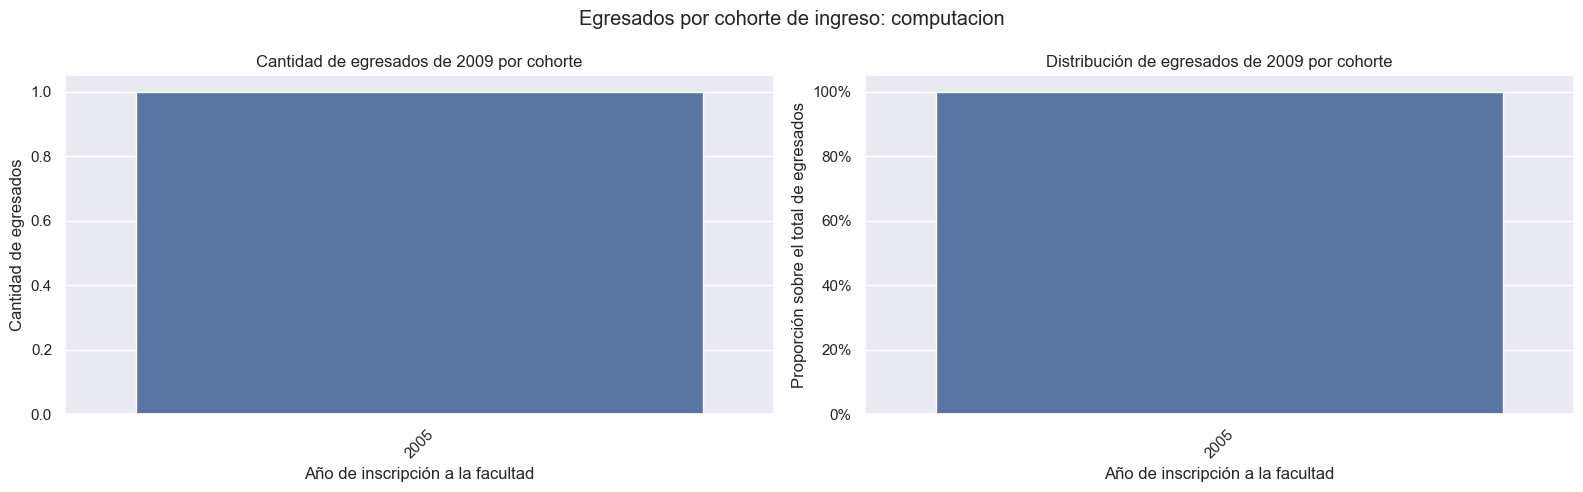

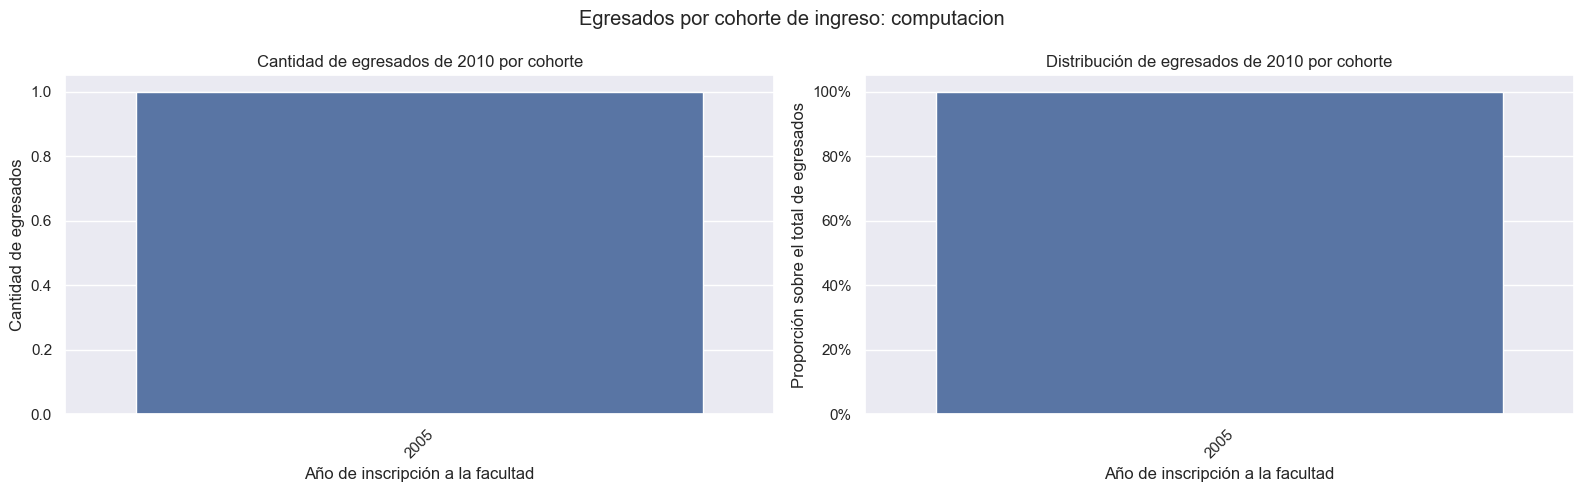

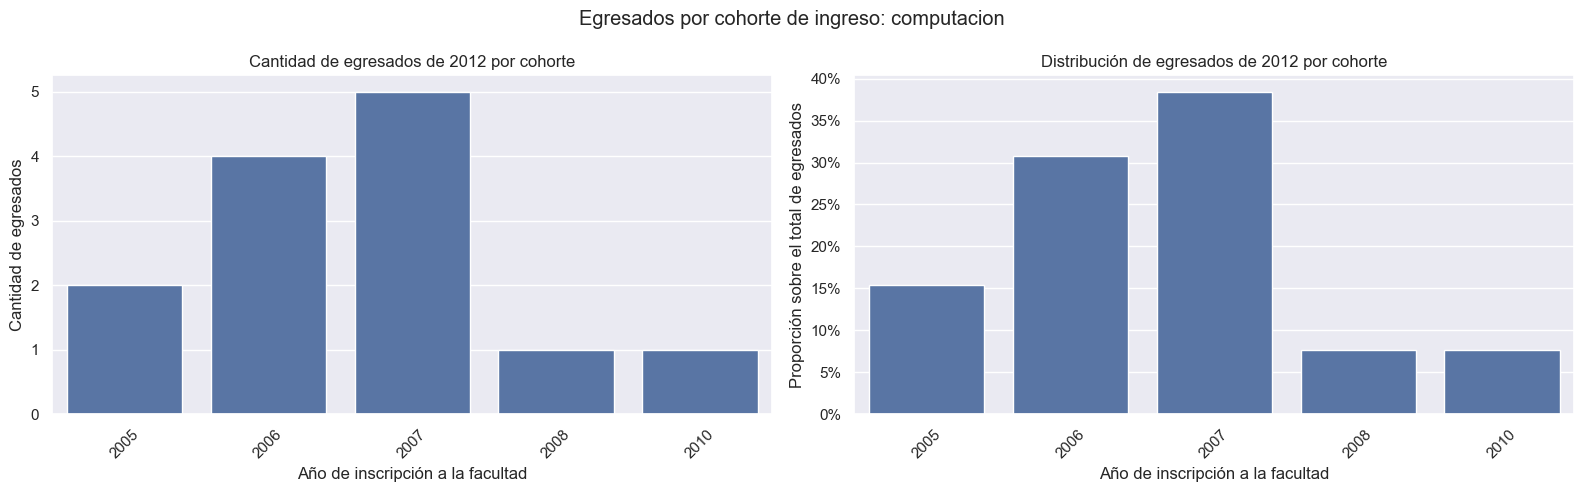

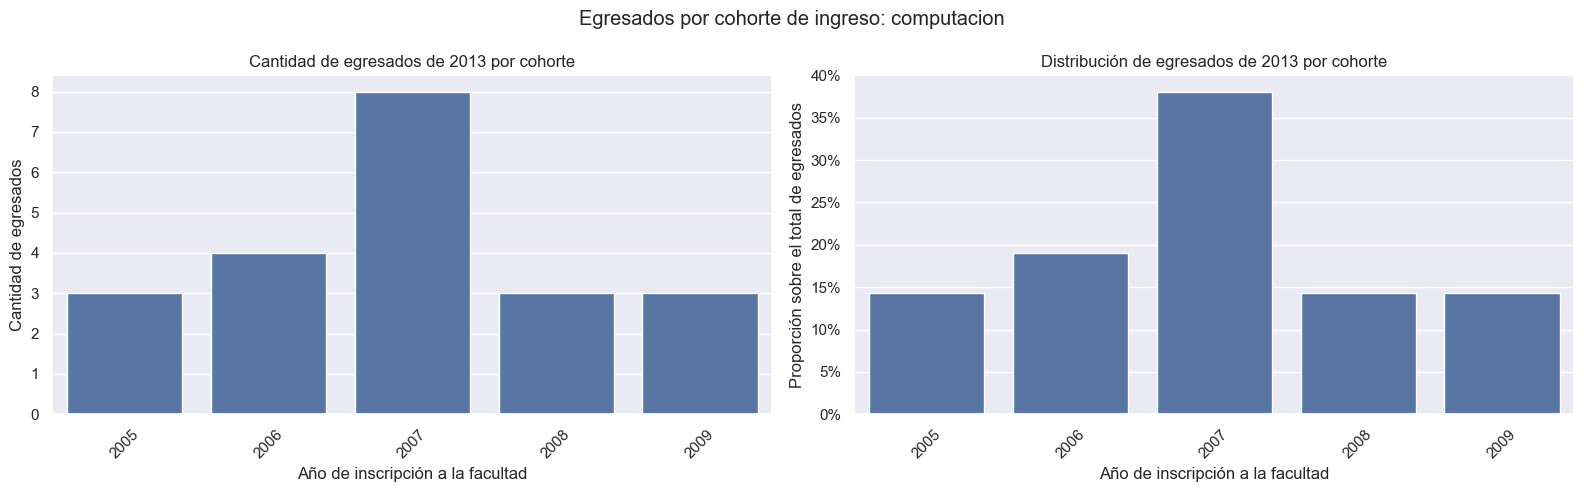

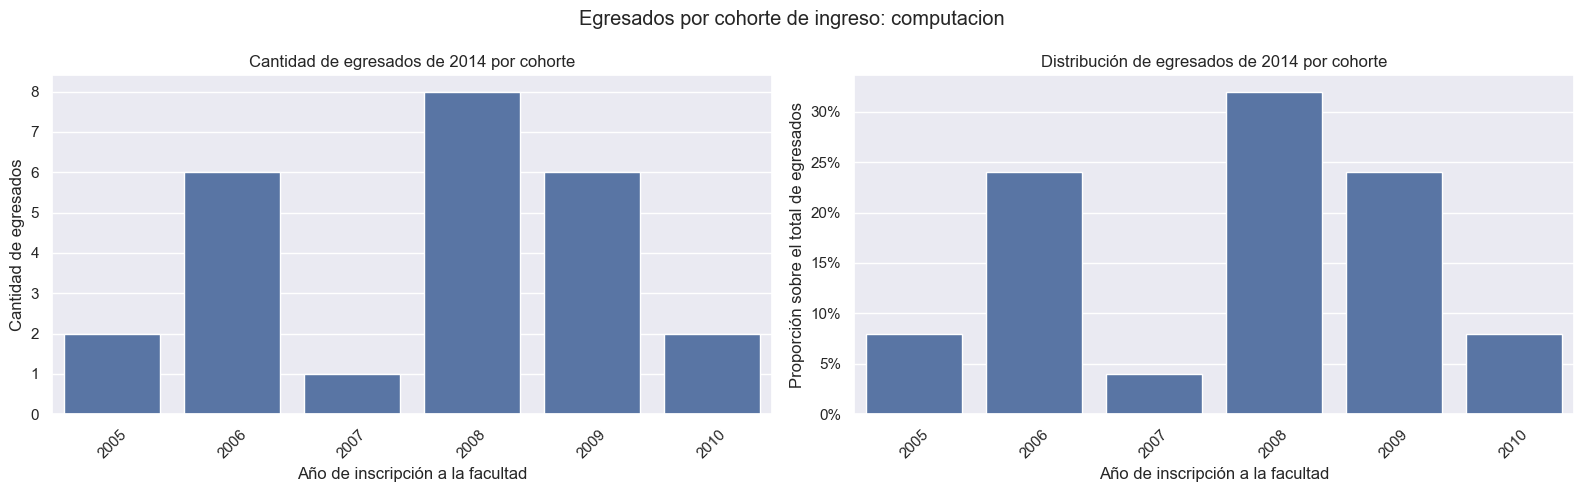

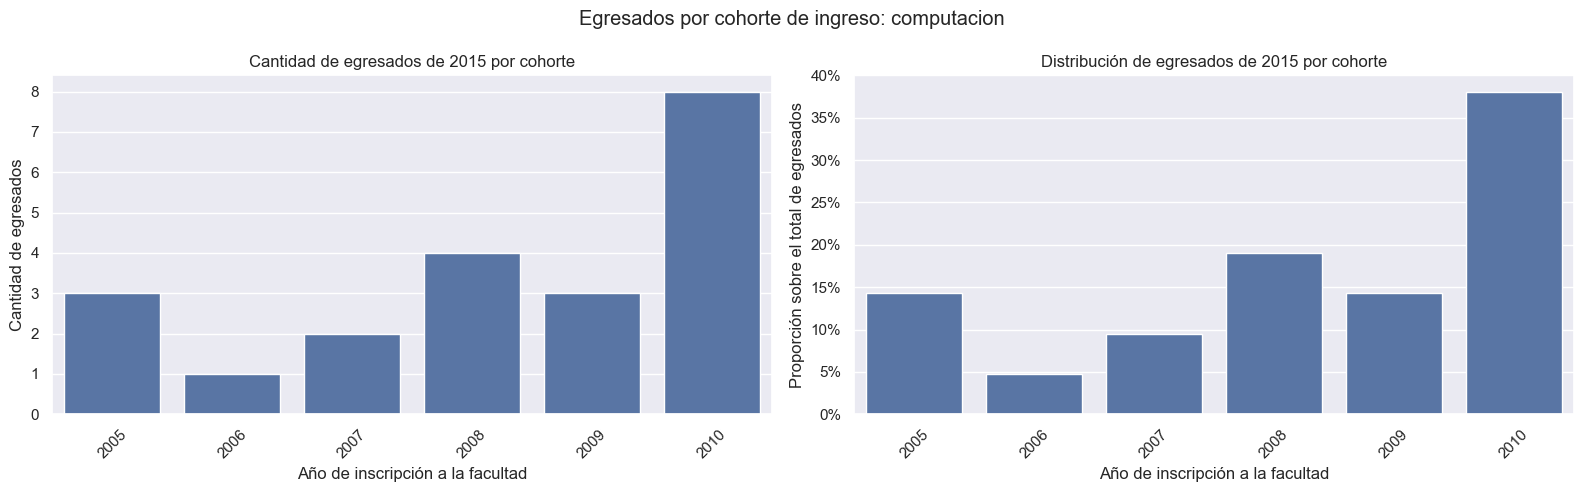

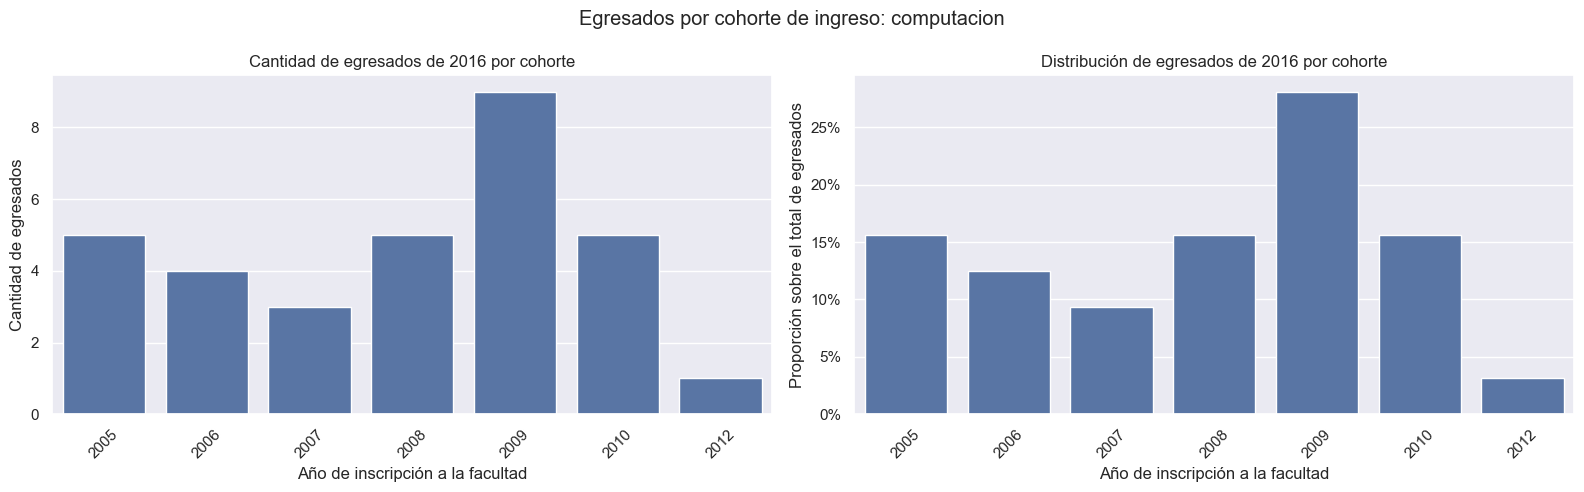

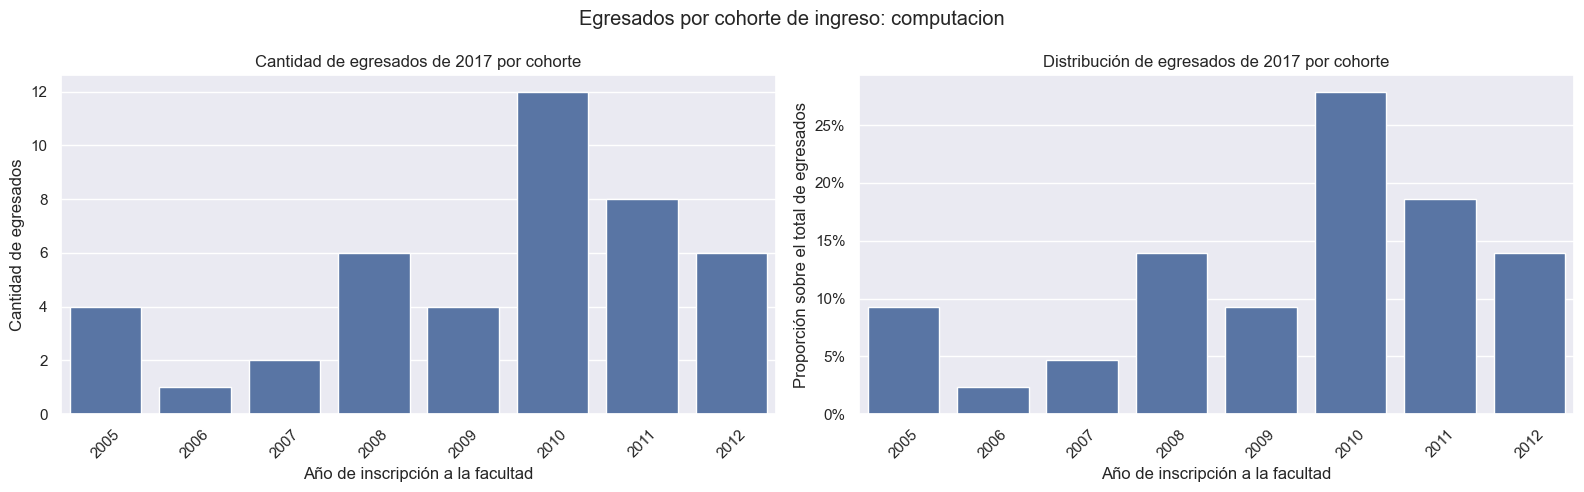

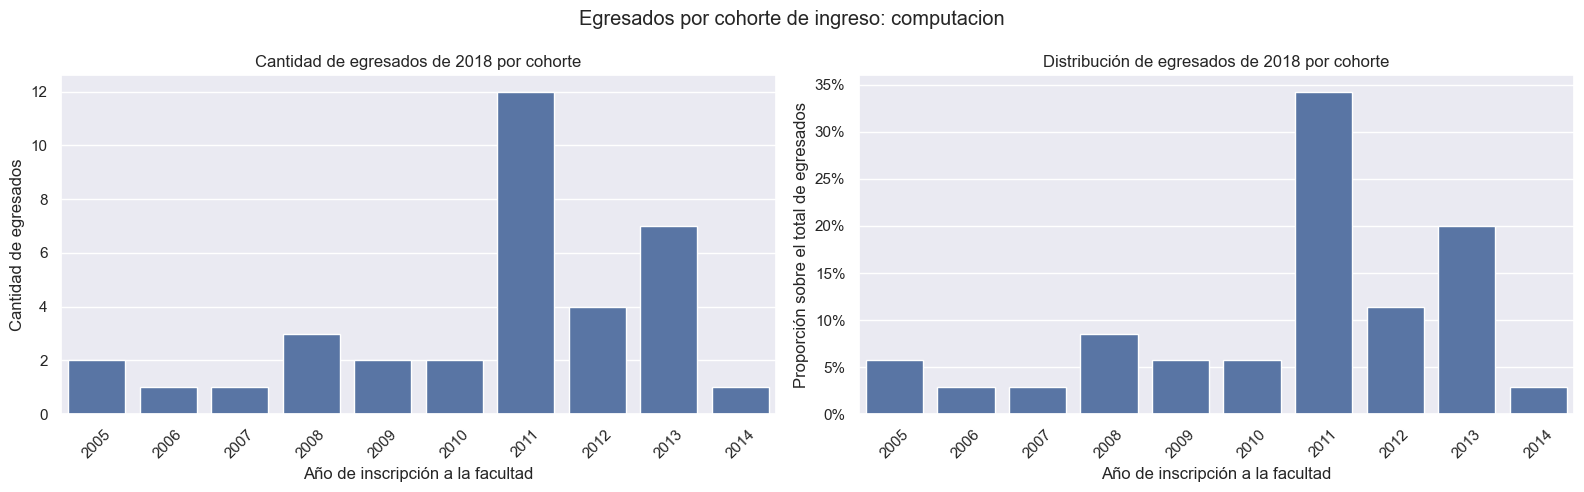

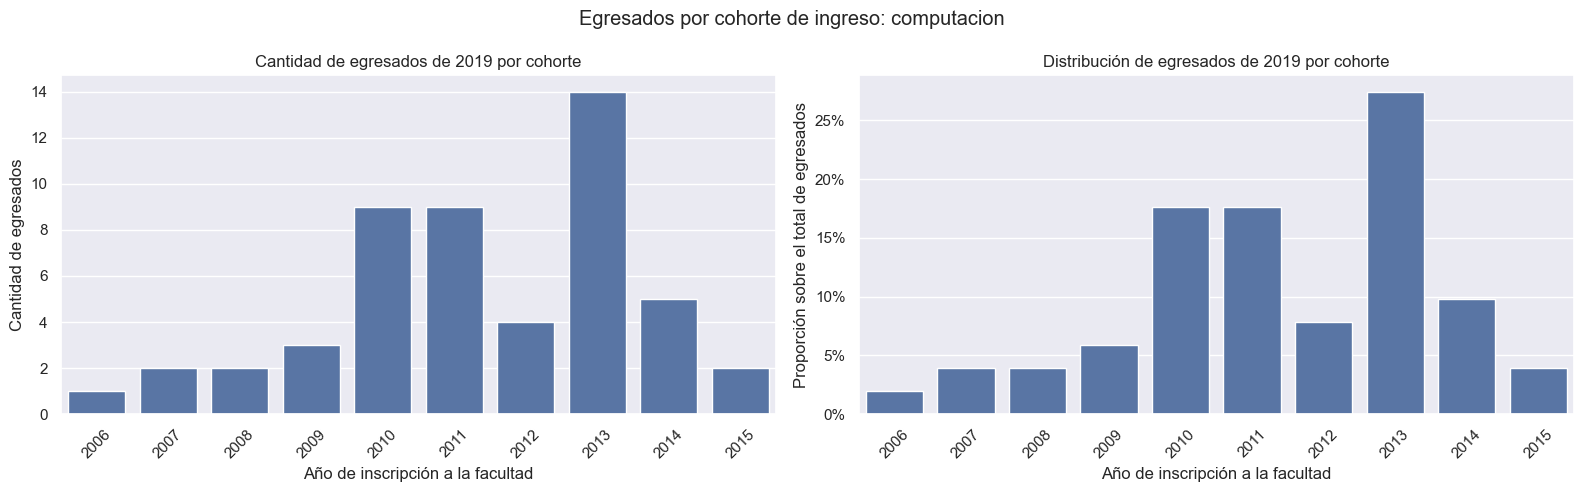

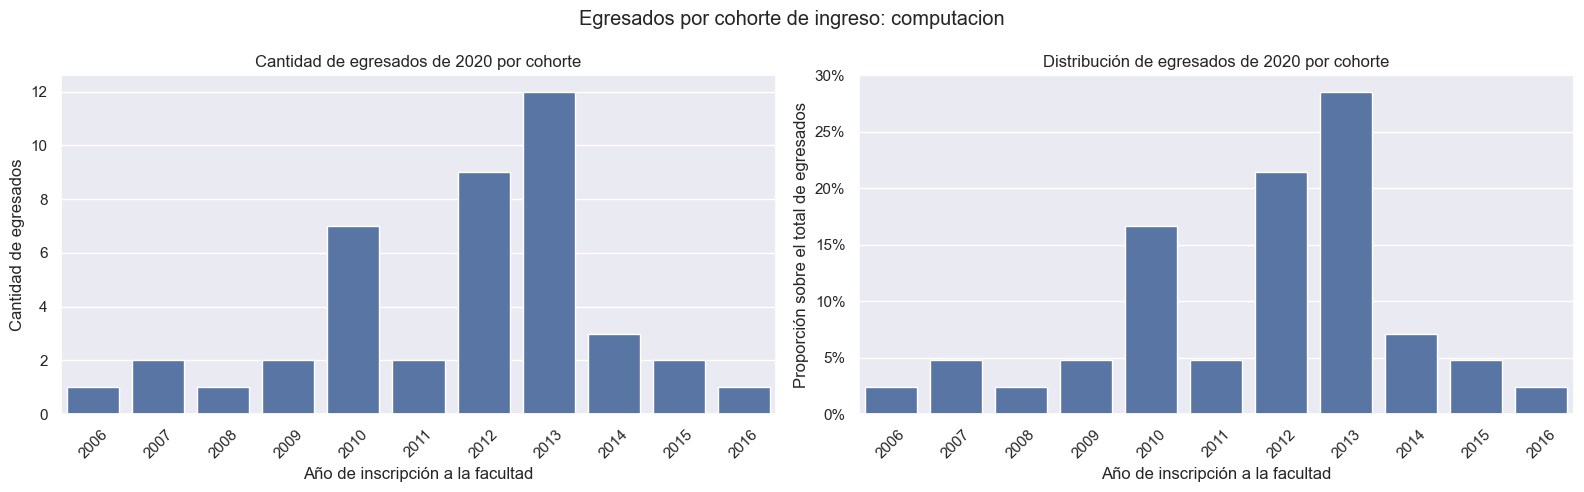

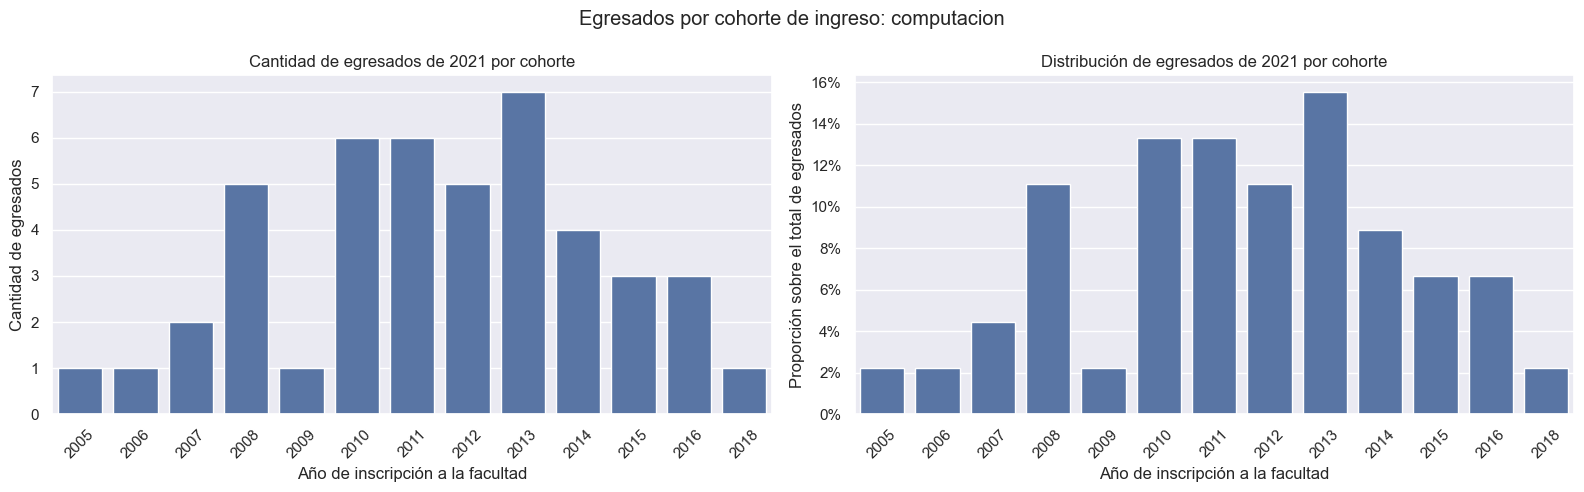

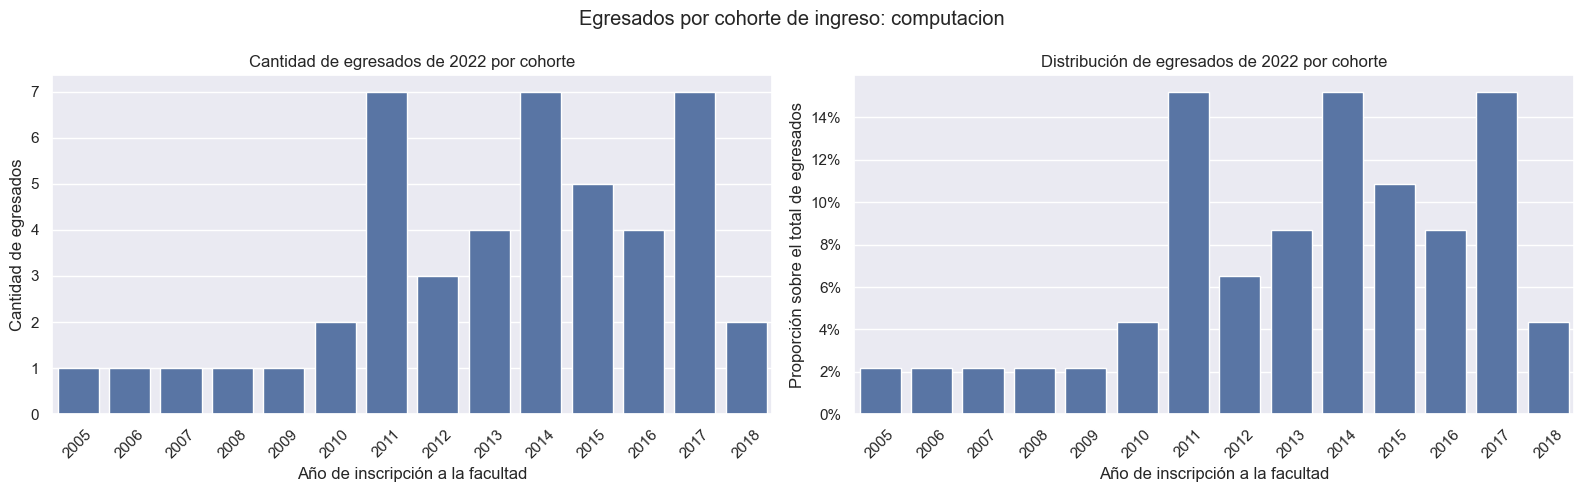

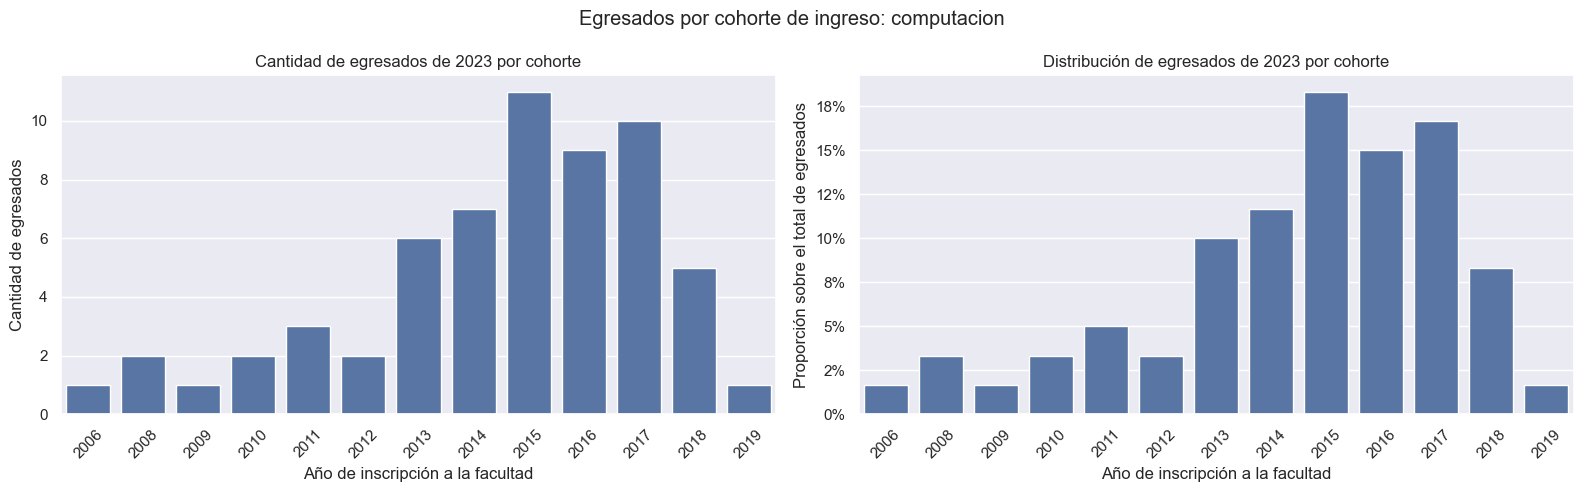

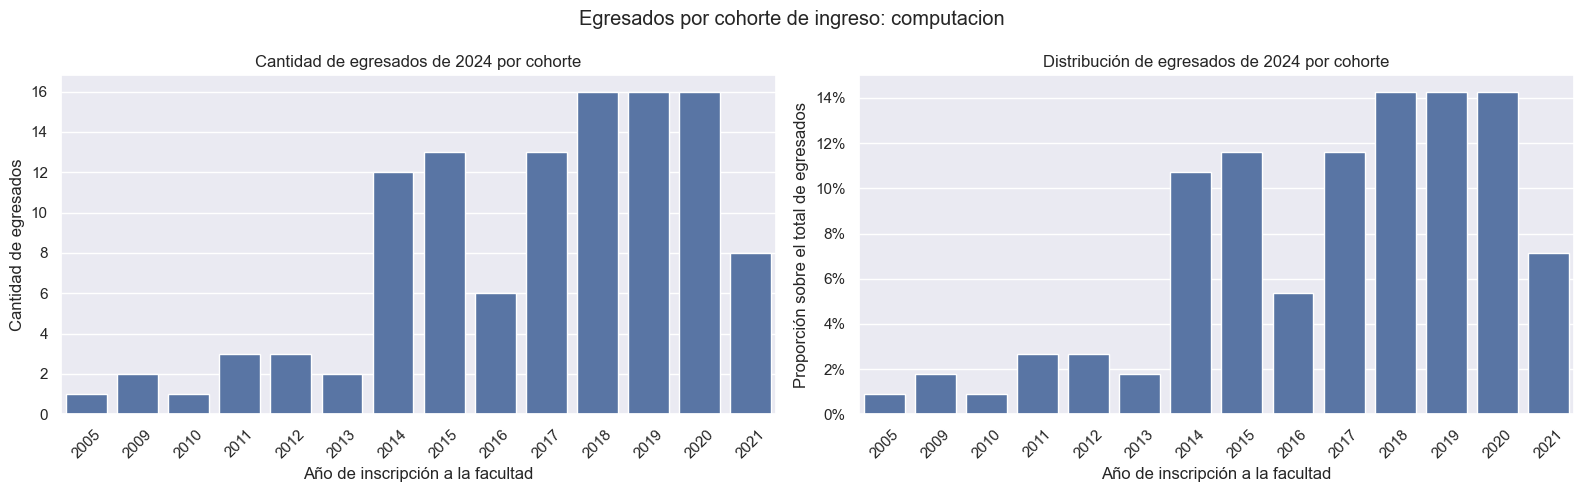

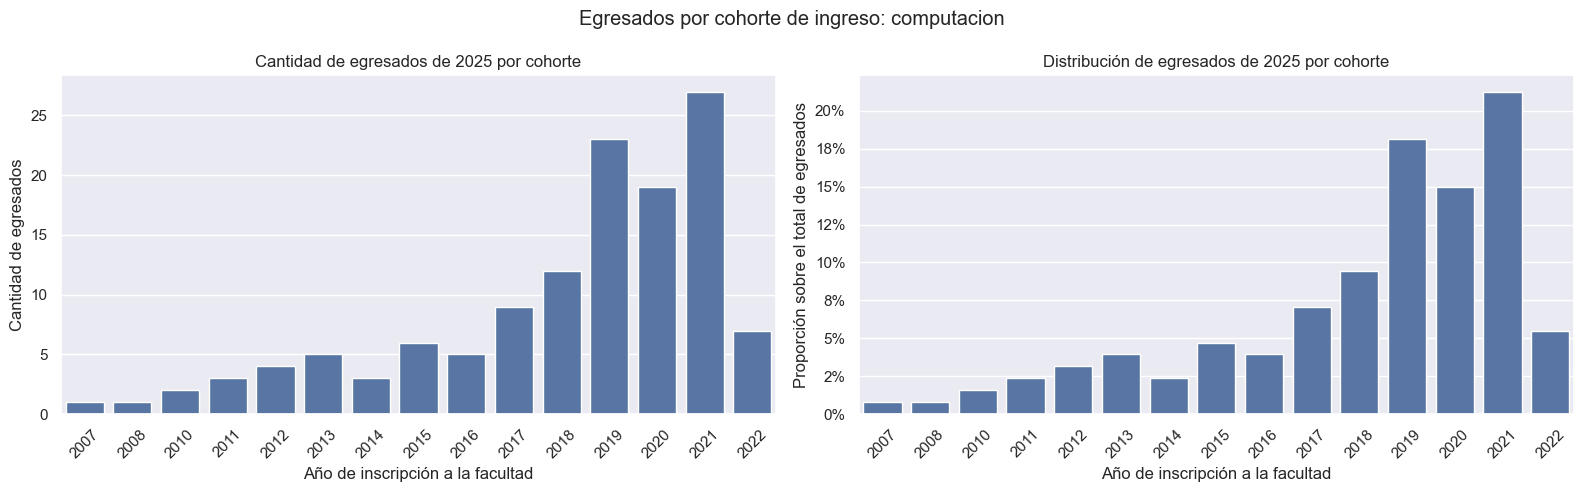

In [12]:
egresados = get_egresados_computacion(
    carreras=['Licenciatura en Ciencias de la Computación'],
    path_yaml='../../constants/materias_computacion.yaml',
    min_materias_obligatorias = 15,
    min_materias_optativas = 3,
    todos_los_planes = False
)
plot_todos_anios_egreso(egresados, 'Computación')

In [13]:
egresados_computacion_2014_2019 = pd.DataFrame()
for anio in range(2014, 2020):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/computacion/resumen_egresados_computacion_{anio}.csv')
    egresados_computacion_2014_2019 = pd.concat([egresados_computacion_2014_2019, egresados])

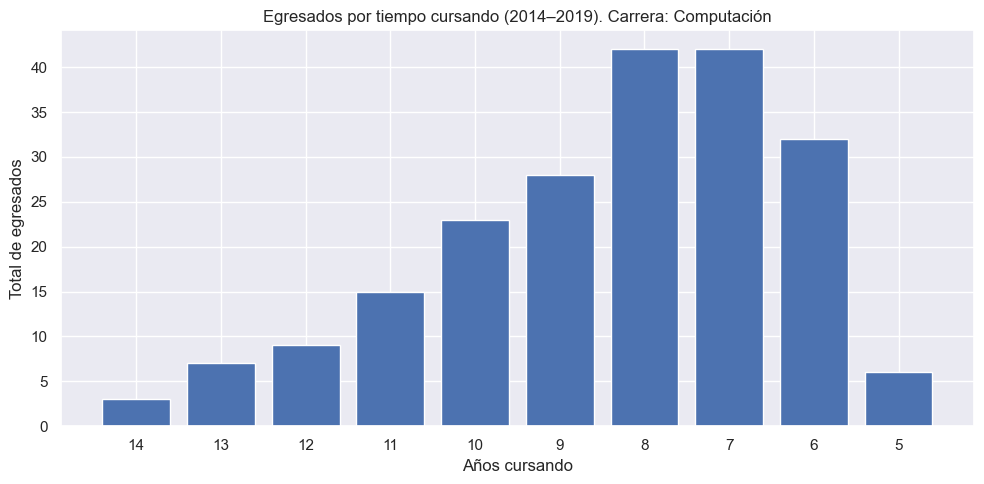

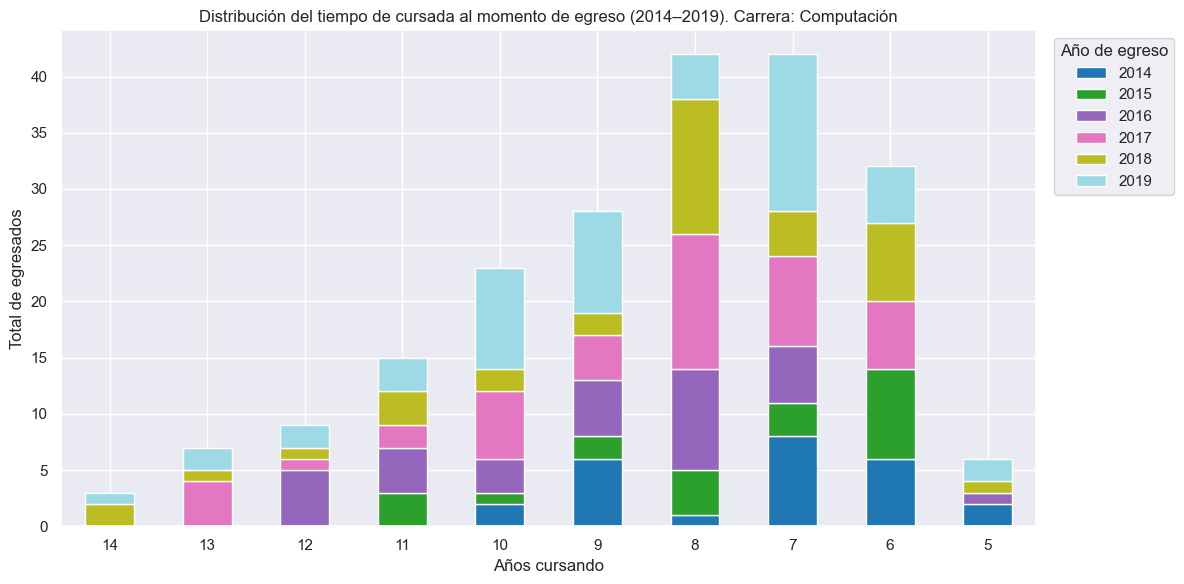

 tiempo_cursando  total_egreso
              14             3
              13             7
              12             9
              11            15
              10            23
               9            28
               8            42
               7            42
               6            32
               5             6
anio_egreso      2014  2015  2016  2017  2018  2019
tiempo_cursando                                    
14                  0     0     0     0     2     1
13                  0     0     0     4     1     2
12                  0     0     5     1     1     2
11                  0     3     4     2     3     3
10                  2     1     3     6     2     9
9                   6     2     5     4     2     9
8                   1     4     9    12    12     4
7                   8     3     5     8     4    14
6                   6     8     0     6     7     5
5                   2     0     1     0     1     2


In [14]:
plot_tiempo_cursando(egresados_computacion_2014_2019, 'Computación', anio_desde=2014, anio_hasta=2019)